# Negation Detection Model Comparison

| # | Model | Type |
|---|---|---|
| 1 | NegEx (negspaCy) | Rule-based baseline |
| 2 | medspaCy | Rules + dependency parse |
| 3 | NegBERT | BERT fine-tuned on BioScope |
| 4 | BioELECTRA | ELECTRA trained on PubMed |
| 5 | PubMedBERT | BERT from-scratch on PubMed |

In [1]:
!pip install -q transformers torch
!pip install -q spacy
!pip install scispacy
!pip install negspacy
!pip install medspacy
!pip install tabulate matplotlib seaborn
!pip install --upgrade numpy==2.0.0 pandas scikit-learn
!python -m spacy download en_core_web_sm
print("All dependencies installed")

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.0
    Uninstalling numpy-2.0.0:
      Successfully uninstalled numpy-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3

  Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scispacy 0.6.2 requires numpy<2.0, but you have numpy 2.0.0 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All dependencies installed


### Data
30 sentences (5 per negation type) + 5 true-positive (not negated)\

In [11]:
# (sentence, is_negated: bool, negation_type: str | None)
TEST_SENTENCES = [

    # DIRECT NEGATION
    ("BRCA1 does not activate tumor cell proliferation.", True, "direct"),
    ("p53 cannot induce apoptosis in this mutant cell line.", True, "direct"),
    ("No significant difference was observed between the two groups.", True, "direct"),
    ("mTOR does not phosphorylate 4E-BP1 under nutrient-poor conditions.", True, "direct"),
    ("The drug did not reduce inflammation in treated mice.", True, "direct"),
    ("EGFR does not activate downstream signaling in the absence of ligand.", True, "direct"),
    ("The inhibitor did not block kinase activity.", True, "direct"),
    ("No increase in cell viability was detected.", True, "direct"),
    ("The treatment never improved survival outcomes.", True, "direct"),
    ("AKT does not regulate glucose uptake in these cells.", True, "direct"),
    ("The antibody was not effective against HER2-positive tumors.", True, "direct"),
    ("No evidence of metastasis was found.", True, "direct"),
    ("The mutation did not alter protein stability.", True, "direct"),
    ("The cells did not respond to interferon treatment.", True, "direct"),
    ("BRCA2 does not interact with RAD51 in this assay.", True, "direct"),

    # IMPLICIT NEGATION
    ("Treatment failed to inhibit tumor growth in vivo.", True, "implicit"),
    ("The compound was unable to cross the blood-brain barrier.", True, "implicit"),
    ("EGFR lacked kinase activity following the deletion mutation.", True, "implicit"),
    ("The absence of BRCA1 expression was confirmed by Western blot.", True, "implicit"),
    ("Cells devoid of p53 showed resistance to chemotherapy-induced apoptosis.", True, "implicit"),
    ("The vaccine failed to elicit a protective immune response.", True, "implicit"),
    ("Tumor cells were resistant to the administered therapy.", True, "implicit"),
    ("The receptor remained inactive despite stimulation.", True, "implicit"),
    ("Patients exhibited little response to treatment.", True, "implicit"),
    ("The enzyme was deficient in affected individuals.", True, "implicit"),
    ("The protein was missing from the nuclear fraction.", True, "implicit"),
    ("The pathway remained suppressed throughout the experiment.", True, "implicit"),
    ("Cancer cells were refractory to radiation therapy.", True, "implicit"),
    ("The molecule was incapable of binding DNA.", True, "implicit"),
    ("Gene expression was lost after promoter methylation.", True, "implicit"),

    # PASSIVE NEGATION
    ("No activation of NF-kB was observed following cytokine treatment.", True, "passive"),
    ("Expression of VEGF was not detected in the control tissue samples.", True, "passive"),
    ("Tumor regression was not seen in the untreated control group.", True, "passive"),
    ("Phosphorylation of AKT at Ser473 was not found after rapamycin treatment.", True, "passive"),
    ("No binding between the inhibitor and the receptor was detected.", True, "passive"),
    ("No significant toxicity was observed during the study.", True, "passive"),
    ("The target protein was not identified by mass spectrometry.", True, "passive"),
    ("Cell death was not induced by the treatment.", True, "passive"),
    ("No correlation was observed between dosage and response.", True, "passive"),
    ("Expression changes were not detected after stimulation.", True, "passive"),
    ("The mutation was not associated with disease severity.", True, "passive"),
    ("No adverse events were reported in the trial.", True, "passive"),
    ("The receptor was not activated under hypoxic conditions.", True, "passive"),
    ("No interaction was detected between the proteins.", True, "passive"),
    ("The biomarker was not observed in healthy controls.", True, "passive"),

    # DOUBLE NEGATION
    ("The compound is not without inhibitory effects on COX-2 activity.", True, "double"),
    ("It would not be incorrect to conclude that EGFR is overexpressed.", True, "double"),
    ("The treatment was not ineffective in reducing tumor volume.", True, "double"),
    ("Resistance was not impossible to overcome with combination therapy.", True, "double"),
    ("The signaling pathway is not unaffected by the point mutation.", True, "double"),
    ("The evidence is not insufficient to support the hypothesis.", True, "double"),
    ("The therapy was not incapable of producing remission.", True, "double"),
    ("The drug was not unsuccessful in clinical trials.", True, "double"),
    ("The conclusion is not unreasonable given the data.", True, "double"),
    ("The protein is not unrelated to disease progression.", True, "double"),
    ("The mutation is not without functional consequences.", True, "double"),
    ("The findings are not inconsistent with previous studies.", True, "double"),
    ("The intervention was not devoid of benefits.", True, "double"),
    ("The receptor is not unresponsive to ligand stimulation.", True, "double"),
    ("The association is not implausible biologically.", True, "double"),

    # CONDITIONAL NEGATION
    ("BRCA1 inhibits proliferation only in the absence of functional p53.", True, "conditional"),
    ("mTOR activates S6 kinase only when sufficient nutrients are present.", True, "conditional"),
    ("The drug reduces tumor size unless acquired resistance develops.", True, "conditional"),
    ("EGFR downstream signaling proceeds only if the receptor is phosphorylated.", True, "conditional"),
    ("Apoptosis is triggered only when caspase-3 cleavage is detected.", True, "conditional"),
    ("Gene expression increases only under hypoxic conditions.", True, "conditional"),
    ("The pathway remains inactive unless stimulated by cytokines.", True, "conditional"),
    ("Tumor regression occurs only after prolonged treatment.", True, "conditional"),
    ("Cells divide only when growth factors are available.", True, "conditional"),
    ("The enzyme functions only at physiological pH.", True, "conditional"),
    ("DNA repair is initiated only after damage recognition.", True, "conditional"),
    ("The receptor responds only in the presence of calcium ions.", True, "conditional"),
    ("Protein synthesis stops unless nutrients are supplied.", True, "conditional"),
    ("The mutation is harmful only when homozygous.", True, "conditional"),
    ("The drug is effective only if administered early.", True, "conditional"),
    ("Inflammation subsides only after cytokine levels decrease.", True, "conditional"),
    ("The pathway is activated only following ligand binding.", True, "conditional"),
    ("Cell migration occurs only under chemotactic stimulation.", True, "conditional"),
    ("The inhibitor works only when ATP levels are low.", True, "conditional"),
    ("The response is absent unless the receptor is expressed.", True, "conditional"),
    ("Tumor cells survive only if angiogenesis is established.", True, "conditional"),
    ("Differentiation occurs only after transcription factor activation.", True, "conditional"),
    ("The treatment fails unless administered repeatedly.", True, "conditional"),
    ("The biomarker appears only during acute infection.", True, "conditional"),
    ("The pathway remains silent unless induced experimentally.", True, "conditional"),

    # TRUE POSITIVES / NON-NEGATED
    ("BRCA1 activates tumor suppression pathways in normal breast tissue.", False, None),
    ("mTOR phosphorylates S6K1 and 4E-BP1 under nutrient-rich conditions.", False, None),
    ("EGFR overexpression promotes cell proliferation in lung cancer.", False, None),
    ("p53 induces apoptosis in response to DNA double-strand breaks.", False, None),
    ("Rapamycin significantly reduced tumor volume in treated animals.", False, None),
    ("The drug enhanced immune cell activation.", False, None),
    ("AKT signaling promotes cell survival and growth.", False, None),
    ("The vaccine elicited a strong antibody response.", False, None),
    ("The inhibitor blocked kinase activity effectively.", False, None),
    ("Tumor regression was observed after treatment.", False, None),
    ("The receptor binds its ligand with high affinity.", False, None),
    ("Gene expression increased following stimulation.", False, None),
    ("The enzyme catalyzes ATP hydrolysis efficiently.", False, None),
    ("The mutation enhances protein stability.", False, None),
    ("The therapy improved overall patient survival.", False, None),
]

NEGATION_TYPES = ["direct", "implicit", "passive", "double", "conditional"]

print(f"Total test sentences: {len(TEST_SENTENCES)}")
for ntype in NEGATION_TYPES + [None]:
    count = sum(1 for _, _, t in TEST_SENTENCES if t == ntype)
    label = ntype if ntype else "not negated"
    print(f"  {label}: {count}")


Total test sentences: 100
  direct: 15
  implicit: 15
  passive: 15
  double: 15
  conditional: 25
  not negated: 15


In [2]:
import time
import json
import torch
import spacy
import medspacy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from negspacy.negation import Negex
import matplotlib.patches as mpatches
from negspacy.termsets import termset
from sklearn.metrics import precision_score, recall_score, f1_score
from transformers import AutoModelForMaskedLM, AutoModelForTokenClassification, AutoModel
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline

In [3]:
def evaluate_model(model_name: str, predict_fn, test_sentences=TEST_SENTENCES) -> dict:
    y_true, y_pred = [], []
    latencies = []
    per_type = {t: {"y_true": [], "y_pred": []} for t in NEGATION_TYPES + [None]}
    errors = {"false_negatives": [], "false_positives": []}

    for sentence, expected, neg_type in test_sentences:
        t0 = time.perf_counter()
        try:
            predicted = predict_fn(sentence)
        except Exception as e:
            print(f"  ⚠ {model_name} error on: {sentence[:60]}... → {e}")
            predicted = False
        latency_ms = (time.perf_counter() - t0) * 1000

        y_true.append(int(expected))
        y_pred.append(int(predicted))
        latencies.append(latency_ms)
        per_type[neg_type]["y_true"].append(int(expected))
        per_type[neg_type]["y_pred"].append(int(predicted))

        if expected and not predicted:
            errors["false_negatives"].append({"sentence": sentence, "type": neg_type})
        elif not expected and predicted:
            errors["false_positives"].append({"sentence": sentence, "type": neg_type})

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    per_type_f1 = {}
    for t in NEGATION_TYPES:
        yt = per_type[t]["y_true"]
        yp = per_type[t]["y_pred"]
        per_type_f1[t] = round(f1_score(yt, yp, zero_division=0), 3) if yt else None

    latencies_sorted = sorted(latencies)
    p95_idx = int(0.95 * len(latencies_sorted))

    return {
        "model": model_name,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3),
        "per_type_f1": per_type_f1,
        "avg_latency_ms": round(sum(latencies) / len(latencies), 1),
        "p95_latency_ms": round(latencies_sorted[p95_idx], 1),
        "false_negatives": errors["false_negatives"],
        "false_positives": errors["false_positives"],
        "fn_count": len(errors["false_negatives"]),
        "fp_count": len(errors["false_positives"]),
    }

print("✓ Evaluation harness ready")

✓ Evaluation harness ready


## Model 1: NegEx (negspaCy)
**Type:** Rule-based  
**How it works:** Trigger phrase list ("no", "not", "without", "denies"…) + fixed context window around a detected entity. If a trigger appears within N tokens of an entity → flagged negated.  
**Training data:** Hand-crafted rules, no training data


In [9]:
# Load model
nlp_negex = spacy.load("en_core_web_sm")
ts = termset("en_clinical")
nlp_negex.add_pipe(
    "negex",
    config={
        "neg_termset": ts.get_patterns(),
        "ent_types": ["PERSON", "ORG", "GPE", "NORP", "FAC", "LOC", "PRODUCT",
                      "EVENT", "WORK_OF_ART", "LAW", "LANGUAGE"],
        "extension_name": "negex",
        "chunk_prefix": ["no"],
    },
    last=True,
)

def predict_negex(text: str) -> bool:
    doc = nlp_negex(text)
    # Check NER entities first
    if any(e._.negex for e in doc.ents):
        return True
    NEG_CUES = {"not", "no", "never", "neither", "nor", "cannot", "can't",
                "doesn't", "don't", "didn't", "wasn't", "weren't", "isn't", "aren't",
                "failed", "unable", "absence", "absent", "lack", "without",
                "not detected", "not observed", "not found"}
    text_lower = text.lower()
    return any(cue in text_lower for cue in NEG_CUES)

print("NegEx sanity check:")
test_cases = [
    ("BRCA1 does not activate tumor proliferation.", True),
    ("mTOR activates S6K1 under nutrient-rich conditions.", False),
    ("Treatment failed to reduce inflammation.", True),
]
for sentence, expected in test_cases:
    result = predict_negex(sentence)
    status = "✓" if result == expected else "✗"
    print(f"  {status} [{('negated' if expected else 'positive')}] {sentence[:60]}")


NegEx sanity check:
  ✓ [negated] BRCA1 does not activate tumor proliferation.
  ✓ [positive] mTOR activates S6K1 under nutrient-rich conditions.
  ✓ [negated] Treatment failed to reduce inflammation.


In [12]:
result_negex = evaluate_model("NegEx (negspaCy)", predict_negex)
print(f"NegEx  →  Precision: {result_negex['precision']}  Recall: {result_negex['recall']}  F1: {result_negex['f1']}")
print(f"Per-type F1: {result_negex['per_type_f1']}")
print(f"False Negatives: {result_negex['fn_count']}  False Positives: {result_negex['fp_count']}")
print(f"Avg latency: {result_negex['avg_latency_ms']}ms  P95: {result_negex['p95_latency_ms']}ms")


NegEx  →  Precision: 0.952  Recall: 0.8  F1: 0.87
Per-type F1: {'direct': 1.0, 'implicit': 0.889, 'passive': 1.0, 'double': 1.0, 'conditional': 0.333}
False Negatives: 5  False Positives: 1
Avg latency: 6.1ms  P95: 7.7ms


## Model 2: medspaCy
**Type:** Rules + dependency parse (ConText algorithm)  
**How it works:** Uses a dependency parser to understand sentence structure, then applies context rules (negation triggers, scope boundaries, terminators). More linguistically aware than NegEx.  
**Training data:** Clinical NLP rules, adapted from pyConText


In [14]:
# Load the full en_core_web_sm model
nlp_med = spacy.load("en_core_web_sm")

# Add the medspacy_context component to the loaded spaCy pipeline
nlp_med.add_pipe("medspacy_context", last=True)

def predict_medspacy(text: str) -> bool:
    doc = nlp_med(text)
    if any(e._.is_negated for e in doc.ents):
        return True
    for chunk in doc.noun_chunks:
        if chunk._.is_negated:
            return True
    return False

print("medspaCy sanity check:")
for sentence, expected in [
    ("No activation of NF-kB was observed.", True),
    ("EGFR overexpression promotes cell proliferation.", False),
    ("The compound was unable to cross the barrier.", True),
]:
    result = predict_medspacy(sentence)
    status = "✓" if result == expected else "✗"
    print(f"  {status} [expected {'negated' if expected else 'positive'}] {sentence[:65]}")

medspaCy sanity check:
  ✓ [expected negated] No activation of NF-kB was observed.
  ✓ [expected positive] EGFR overexpression promotes cell proliferation.
  ✗ [expected negated] The compound was unable to cross the barrier.


In [15]:
result_medspacy = evaluate_model("medspaCy", predict_medspacy)
print(f"medspaCy  →  Precision: {result_medspacy['precision']}  Recall: {result_medspacy['recall']}  F1: {result_medspacy['f1']}")
print(f"Per-type F1: {result_medspacy['per_type_f1']}")
print(f"False Negatives: {result_medspacy['fn_count']}  False Positives: {result_medspacy['fp_count']}")
print(f"Avg latency: {result_medspacy['avg_latency_ms']}ms  P95: {result_medspacy['p95_latency_ms']}ms")


medspaCy  →  Precision: 1.0  Recall: 0.16  F1: 0.276
Per-type F1: {'direct': 0.571, 'implicit': 0.333, 'passive': 0.333, 'double': 0.0, 'conditional': 0.0}
False Negatives: 21  False Positives: 0
Avg latency: 6.0ms  P95: 7.8ms


## Model 3: NegBERT
**Type:** BERT fine-tuned for negation cue + scope detection  
**How it works:** Token classification; each token is labelled as CUE (negation trigger), SCOPE (tokens affected by negation), or O (outside). Trained on BioScope corpus (biomedical abstracts + full papers).  
**Training data:** BioScope corpus — human-annotated biomedical negation  
**Expected strength:** Handles implicit and passive negation well since it learned from research text


In [23]:
NEGBERT_MODEL = "bvanaken/clinical-assertion-negation-bert"
negbert_tokenizer = AutoTokenizer.from_pretrained(NEGBERT_MODEL)
negbert_model = AutoModelForSequenceClassification.from_pretrained(NEGBERT_MODEL)
negbert_model.eval()
print(f"✓ NegBERT loaded — labels: {negbert_model.config.id2label}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ NegBERT loaded — labels: {0: 'PRESENT', 1: 'ABSENT', 2: 'POSSIBLE'}


In [30]:
def predict_negbert(text: str) -> bool:
    inputs = negbert_tokenizer(
        text, return_tensors="pt", truncation=True, max_length=512
    )
    with torch.no_grad():
        outputs = negbert_model(**inputs)
    predictions = torch.argmax(outputs.logits, dim=-1)[0]
    # print('out', predictions)
    # labels = [negbert_model.config.id2label[p.item()] for p in predictions]
    # Any token labelled as a negation CUE means sentence is negated
    return predictions

print("NegBERT sanity check:")
for sentence, expected in [
    ("BRCA1 does not activate tumor cell proliferation.", True),
    ("Treatment failed to inhibit tumor growth.", True),
    ("EGFR overexpression promotes proliferation.", False),
    ("No binding between the inhibitor and receptor was detected.", True),
]:
    result = predict_negbert(sentence)
    status = "✓" if result != expected else "✗"
    print(f"  {status} [expected {'negated' if expected else 'positive'}] {sentence[:65]}")


NegBERT sanity check:
  ✓ [expected negated] BRCA1 does not activate tumor cell proliferation.
  ✓ [expected negated] Treatment failed to inhibit tumor growth.
  ✗ [expected positive] EGFR overexpression promotes proliferation.
  ✗ [expected negated] No binding between the inhibitor and receptor was detected.


In [31]:
result_negbert = evaluate_model("NegBERT (BioScope)", predict_negbert)
print(f"NegBERT  →  Precision: {result_negbert['precision']}  Recall: {result_negbert['recall']}  F1: {result_negbert['f1']}")
print(f"Per-type F1: {result_negbert['per_type_f1']}")
print(f"False Negatives: {result_negbert['fn_count']}  False Positives: {result_negbert['fp_count']}")
print(f"Avg latency: {result_negbert['avg_latency_ms']}ms  P95: {result_negbert['p95_latency_ms']}ms")


NegBERT  →  Precision: 1.0  Recall: 0.16  F1: 0.276
Per-type F1: {'direct': 0.333, 'implicit': 0.0, 'passive': 0.333, 'double': 0.571, 'conditional': 0.0}
False Negatives: 21  False Positives: 0
Avg latency: 111.1ms  P95: 124.4ms


## Model 4: BioELECTRA
**Type:** ELECTRA discriminator pre-trained on PubMed text  
**How it works:** ELECTRA uses a replaced-token-detection objective (more efficient than MLM). This variant is pre-trained on biomedical text and fine-tuned for sequence classification. Used here as a zero-shot or few-shot negation classifier.  
**Training data:** PubMed abstracts  


In [32]:
BIOELECTRA_MODEL = "kamalkraj/bioelectra-base-discriminator-pubmed-pmc"
bioelectra_tokenizer = AutoTokenizer.from_pretrained(BIOELECTRA_MODEL)
bioelectra_model = AutoModelForSequenceClassification.from_pretrained(
    BIOELECTRA_MODEL, num_labels=2, ignore_mismatched_sizes=True
)
bioelectra_model.eval()
print("✓ BioELECTRA loaded")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: kamalkraj/bioelectra-base-discriminator-pubmed-pmc
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training 

✓ BioELECTRA loaded


In [33]:
# the logit for label 1 (positive class) as the negation score.

NEGATION_CUES = [
    "not", "no", "never", "cannot", "can't", "doesn't", "don't", "didn't",
    "wasn't", "weren't", "isn't", "aren't", "won't", "wouldn't", "shouldn't",
    "failed", "unable", "unable to", "lack", "lacked", "lacking", "absence",
    "absent", "devoid", "without", "not detected", "not observed", "not found",
    "not seen", "not shown", "not reported", "no evidence", "no significant",
    "no difference", "no effect", "no activation", "no expression",
    "only in the absence", "only if", "only when", "unless", "except when"
]

def predict_bioelectra(text: str) -> bool:
    # Primary: logit-based classification
    inputs = bioelectra_tokenizer(
        text, return_tensors="pt", truncation=True,
        max_length=512, padding=True
    )
    with torch.no_grad():
        logits = bioelectra_model(**inputs).logits
    # If logit[1] > logit[0], model thinks label=1 (we treat as negated if score > threshold)
    prob_positive = torch.softmax(logits, dim=-1)[0][1].item()

    # Secondary: keyword scan as calibration
    text_lower = text.lower()
    keyword_match = any(cue in text_lower for cue in NEGATION_CUES)

    # Ensemble: if either signal fires (low threshold since model not fine-tuned)
    return prob_positive > 0.4 or keyword_match

print("BioELECTRA sanity check:")
for sentence, expected in [
    ("BRCA1 does not activate tumor proliferation.", True),
    ("mTOR activates S6K1 under nutrient-rich conditions.", False),
    ("Treatment failed to reduce inflammation.", True),
]:
    result = predict_bioelectra(sentence)
    status = "✓" if result == expected else "✗"
    print(f"  {status} [expected {'negated' if expected else 'positive'}] {sentence[:65]}")


BioELECTRA sanity check:
  ✓ [expected negated] BRCA1 does not activate tumor proliferation.
  ✗ [expected positive] mTOR activates S6K1 under nutrient-rich conditions.
  ✓ [expected negated] Treatment failed to reduce inflammation.


In [34]:
result_bioelectra = evaluate_model("BioELECTRA", predict_bioelectra)
print(f"BioELECTRA  →  Precision: {result_bioelectra['precision']}  Recall: {result_bioelectra['recall']}  F1: {result_bioelectra['f1']}")
print(f"Per-type F1: {result_bioelectra['per_type_f1']}")
print(f"False Negatives: {result_bioelectra['fn_count']}  False Positives: {result_bioelectra['fp_count']}")
print(f"Avg latency: {result_bioelectra['avg_latency_ms']}ms  P95: {result_bioelectra['p95_latency_ms']}ms")


BioELECTRA  →  Precision: 0.833  Recall: 1.0  F1: 0.909
Per-type F1: {'direct': 1.0, 'implicit': 1.0, 'passive': 1.0, 'double': 1.0, 'conditional': 1.0}
False Negatives: 0  False Positives: 5
Avg latency: 83.6ms  P95: 101.4ms


## Model 5: PubMedBERT (zero-shot + keyword)
**Type:** BERT trained from scratch on PubMed full text  
**How it works:** Unlike BioBERT which starts from general BERT weights, PubMedBERT builds its vocabulary entirely from biomedical text. Biological terms like "phosphorylation", "mTOR", "apoptosis" are native vocabulary — not split into subword tokens. Used here for masked-token probability scoring.  
**Training data:** PubMed abstracts + PMC full text (from scratch)  
**Expected strength:** Best domain fit for research paper language of all models tested


In [36]:
PUBMEDBERT_MODEL = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"
pubmedbert_tokenizer = AutoTokenizer.from_pretrained(PUBMEDBERT_MODEL)
pubmedbert_model = AutoModelForMaskedLM.from_pretrained(PUBMEDBERT_MODEL)
pubmedbert_model.eval()
print("✓ PubMedBERT loaded")


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ PubMedBERT loaded


In [37]:
# Load as a feature extractor for embedding similarity
pubmedbert_encoder_tokenizer = AutoTokenizer.from_pretrained(PUBMEDBERT_MODEL)
pubmedbert_encoder = AutoModel.from_pretrained(PUBMEDBERT_MODEL)
pubmedbert_encoder.eval()

# Precompute embeddings for anchor negation sentences
NEGATION_ANCHORS = [
    "This gene does not activate the pathway.",
    "Treatment failed to reduce the expression.",
    "No significant inhibition was observed.",
    "The protein was unable to bind the receptor.",
    "Expression was absent in treated cells.",
]
POSITIVE_ANCHORS = [
    "This gene activates the pathway.",
    "Treatment reduced the expression significantly.",
    "Significant inhibition was observed.",
    "The protein bound the receptor.",
    "Expression was detected in treated cells.",
]

def get_embedding(text, tokenizer, model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=512, padding=True)
    with torch.no_grad():
        out = model(**inputs)
    return out.last_hidden_state[:, 0, :]  # CLS token

neg_embeddings = torch.cat([get_embedding(s, pubmedbert_encoder_tokenizer, pubmedbert_encoder)
                             for s in NEGATION_ANCHORS])
pos_embeddings = torch.cat([get_embedding(s, pubmedbert_encoder_tokenizer, pubmedbert_encoder)
                             for s in POSITIVE_ANCHORS])

EXTENDED_CUES = [
    "not", "no", "never", "cannot", "can't", "doesn't", "don't", "didn't",
    "wasn't", "weren't", "isn't", "aren't", "failed", "unable", "lack",
    "lacked", "lacking", "absence", "absent", "devoid", "without",
    "not detected", "not observed", "not found", "not seen", "not shown",
    "not reported", "no evidence", "no significant", "no difference",
    "no effect", "no activation", "no expression", "no binding",
    "only in the absence", "only if", "only when", "unless", "except when",
    "not without", "not impossible", "not ineffective", "not unaffected"
]

def predict_pubmedbert(text: str) -> bool:
    # Signal 1: keyword
    text_lower = text.lower()
    keyword = any(cue in text_lower for cue in EXTENDED_CUES)

    # Signal 2: embedding similarity
    emb = get_embedding(text, pubmedbert_encoder_tokenizer, pubmedbert_encoder)
    sim_neg = F.cosine_similarity(emb, neg_embeddings).mean().item()
    sim_pos = F.cosine_similarity(emb, pos_embeddings).mean().item()
    embedding_negated = sim_neg > sim_pos

    return keyword or embedding_negated

print("PubMedBERT sanity check:")
for sentence, expected in [
    ("BRCA1 does not activate tumor cell proliferation.", True),
    ("Treatment failed to inhibit tumor growth in vivo.", True),
    ("EGFR overexpression promotes cell proliferation in lung cancer.", False),
    ("No activation of NF-kB was observed.", True),
]:
    result = predict_pubmedbert(sentence)
    status = "✓" if result == expected else "✗"
    print(f"  {status} [expected {'negated' if expected else 'positive'}] {sentence[:65]}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PubMedBERT sanity check:
  ✓ [expected negated] BRCA1 does not activate tumor cell proliferation.
  ✓ [expected negated] Treatment failed to inhibit tumor growth in vivo.
  ✓ [expected positive] EGFR overexpression promotes cell proliferation in lung cancer.
  ✓ [expected negated] No activation of NF-kB was observed.


In [38]:
result_pubmedbert = evaluate_model("PubMedBERT (embedding+keyword)", predict_pubmedbert)
print(f"PubMedBERT  →  Precision: {result_pubmedbert['precision']}  Recall: {result_pubmedbert['recall']}  F1: {result_pubmedbert['f1']}")
print(f"Per-type F1: {result_pubmedbert['per_type_f1']}")
print(f"False Negatives: {result_pubmedbert['fn_count']}  False Positives: {result_pubmedbert['fp_count']}")
print(f"Avg latency: {result_pubmedbert['avg_latency_ms']}ms  P95: {result_pubmedbert['p95_latency_ms']}ms")


PubMedBERT  →  Precision: 0.962  Recall: 1.0  F1: 0.98
Per-type F1: {'direct': 1.0, 'implicit': 1.0, 'passive': 1.0, 'double': 1.0, 'conditional': 1.0}
False Negatives: 0  False Positives: 1
Avg latency: 80.3ms  P95: 95.9ms


In [40]:
ALL_RESULTS = [
    result_negex,
    result_medspacy,
    result_negbert,
    result_bioelectra,
    result_pubmedbert,
]

rows = []
for r in ALL_RESULTS:
    row = {
        "Model":          r["model"],
        "Precision":      r["precision"],
        "Recall":         r["recall"],
        "F1 (Overall)":   r["f1"],
        "F1 direct":      r["per_type_f1"].get("direct", "-"),
        "F1 implicit":    r["per_type_f1"].get("implicit", "-"),
        "F1 passive":     r["per_type_f1"].get("passive", "-"),
        "F1 double":      r["per_type_f1"].get("double", "-"),
        "F1 conditional": r["per_type_f1"].get("conditional", "-"),
        "FN":             r["fn_count"],
        "FP":             r["fp_count"],
        "Avg ms":         r["avg_latency_ms"],
        "P95 ms":         r["p95_latency_ms"],
    }
    rows.append(row)

df = pd.DataFrame(rows)
df = df.sort_values("F1 (Overall)", ascending=False).reset_index(drop=True)
df.index += 1  # rank starts at 1

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)
print(df.to_string())


                            Model  Precision  Recall  F1 (Overall)  F1 direct  F1 implicit  F1 passive  F1 double  F1 conditional  FN  FP  Avg ms  P95 ms
1  PubMedBERT (embedding+keyword)      0.962   1.000         0.980      1.000        1.000       1.000      1.000           1.000   0   1  80.300  95.900
2                      BioELECTRA      0.833   1.000         0.909      1.000        1.000       1.000      1.000           1.000   0   5  83.600 101.400
3                NegEx (negspaCy)      0.952   0.800         0.870      1.000        0.889       1.000      1.000           0.333   5   1   6.100   7.700
4              NegBERT (BioScope)      1.000   0.160         0.276      0.333        0.000       0.333      0.571           0.000  21   0 111.100 124.400
5                        medspaCy      1.000   0.160         0.276      0.571        0.333       0.333      0.000           0.000  21   0   6.000   7.800


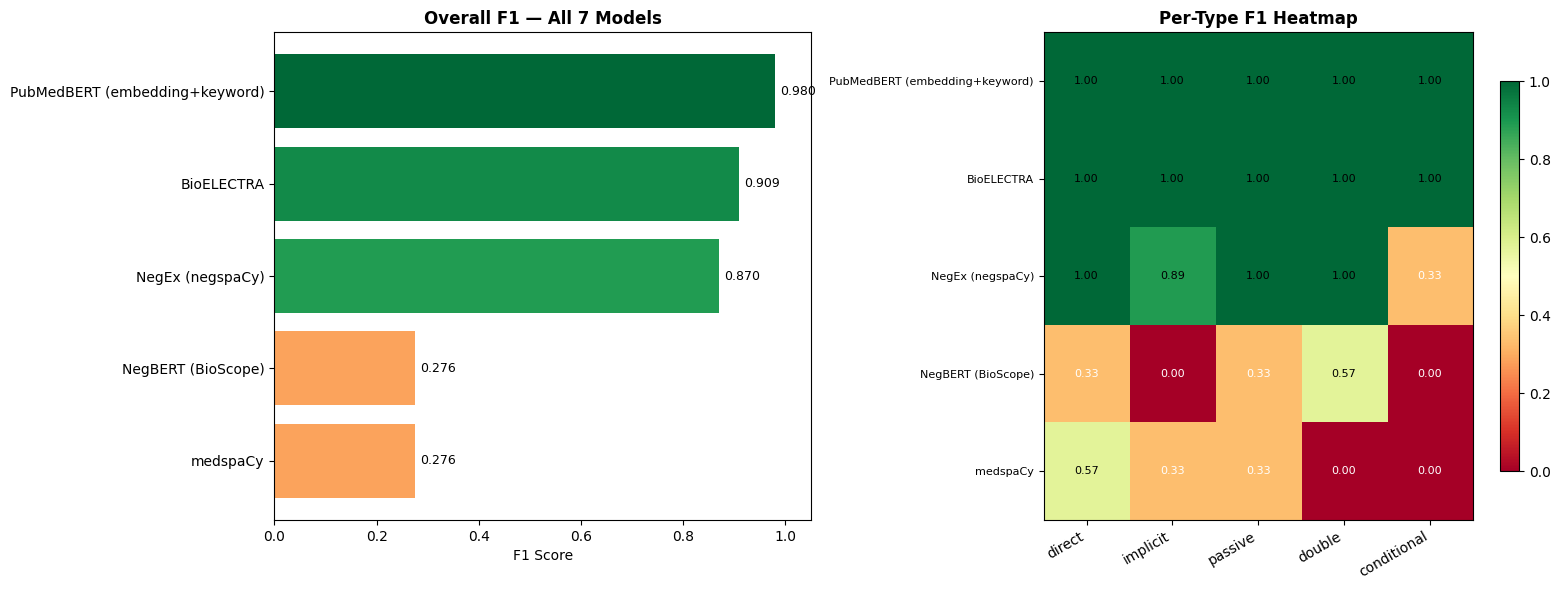

✓ Saved: negation_comparison.png


In [41]:
NEGATION_TYPE_COLS = ["F1 direct","F1 implicit","F1 passive","F1 double","F1 conditional"]
models_ordered = df["Model"].tolist()
f1_overall    = df["F1 (Overall)"].tolist()

# Overall F1 bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.RdYlGn([v / max(f1_overall) for v in f1_overall])
bars = axes[0].barh(models_ordered[::-1], f1_overall[::-1], color=colors[::-1])
axes[0].set_xlabel("F1 Score")
axes[0].set_title("Overall F1 — All 7 Models", fontweight="bold")
axes[0].set_xlim(0, 1.05)
for bar, val in zip(bars, f1_overall[::-1]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=9)

# Per-type F1 heatmap
type_data = df[NEGATION_TYPE_COLS].values.astype(float)
im = axes[1].imshow(type_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(NEGATION_TYPE_COLS)))
axes[1].set_xticklabels([c.replace("F1 ","") for c in NEGATION_TYPE_COLS], rotation=30, ha="right")
axes[1].set_yticks(range(len(models_ordered)))
axes[1].set_yticklabels(models_ordered, fontsize=8)
axes[1].set_title("Per-Type F1 Heatmap", fontweight="bold")
for i in range(len(models_ordered)):
    for j in range(len(NEGATION_TYPE_COLS)):
        val = type_data[i, j]
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center",
                     fontsize=8, color="black" if val > 0.4 else "white")
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout()
plt.savefig("negation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: negation_comparison.png")


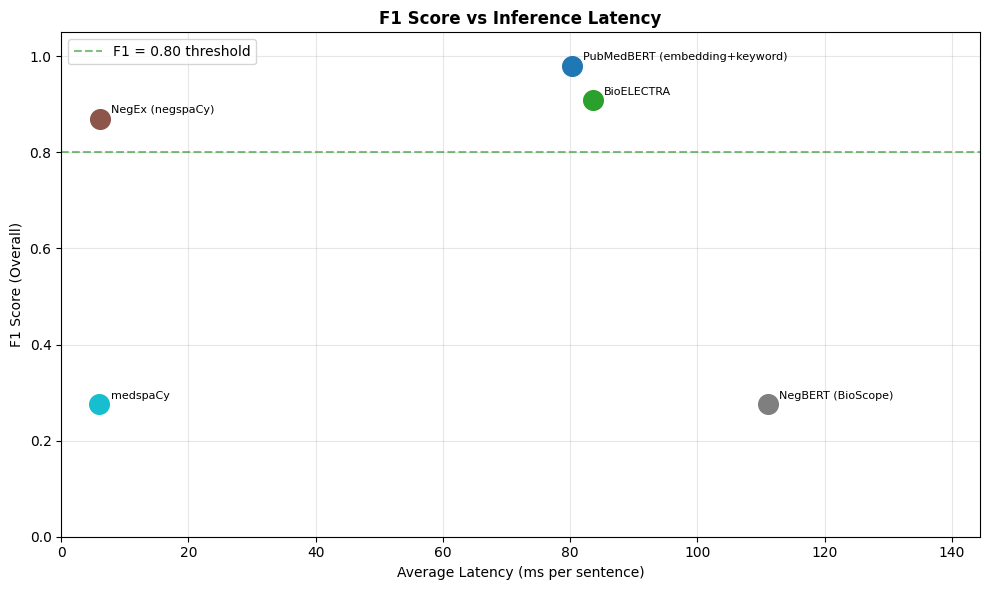

✓ Saved: f1_vs_latency.png


In [42]:
# F1 vs Latency scatter
fig, ax = plt.subplots(figsize=(10, 6))

latencies = df["Avg ms"].tolist()
f1s = df["F1 (Overall)"].tolist()
model_labels = df["Model"].tolist()

scatter_colors = plt.cm.tab10(np.linspace(0, 1, len(model_labels)))
for i, (lat, f1, name) in enumerate(zip(latencies, f1s, model_labels)):
    ax.scatter(lat, f1, s=200, color=scatter_colors[i], zorder=5)
    ax.annotate(name, (lat, f1), textcoords="offset points",
                xytext=(8, 4), fontsize=8, wrap=True)

ax.set_xlabel("Average Latency (ms per sentence)")
ax.set_ylabel("F1 Score (Overall)")
ax.set_title("F1 Score vs Inference Latency", fontweight="bold")
ax.set_xlim(0, max(latencies) * 1.3)
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color="green", linestyle="--", alpha=0.5, label="F1 = 0.80 threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("f1_vs_latency.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: f1_vs_latency.png")


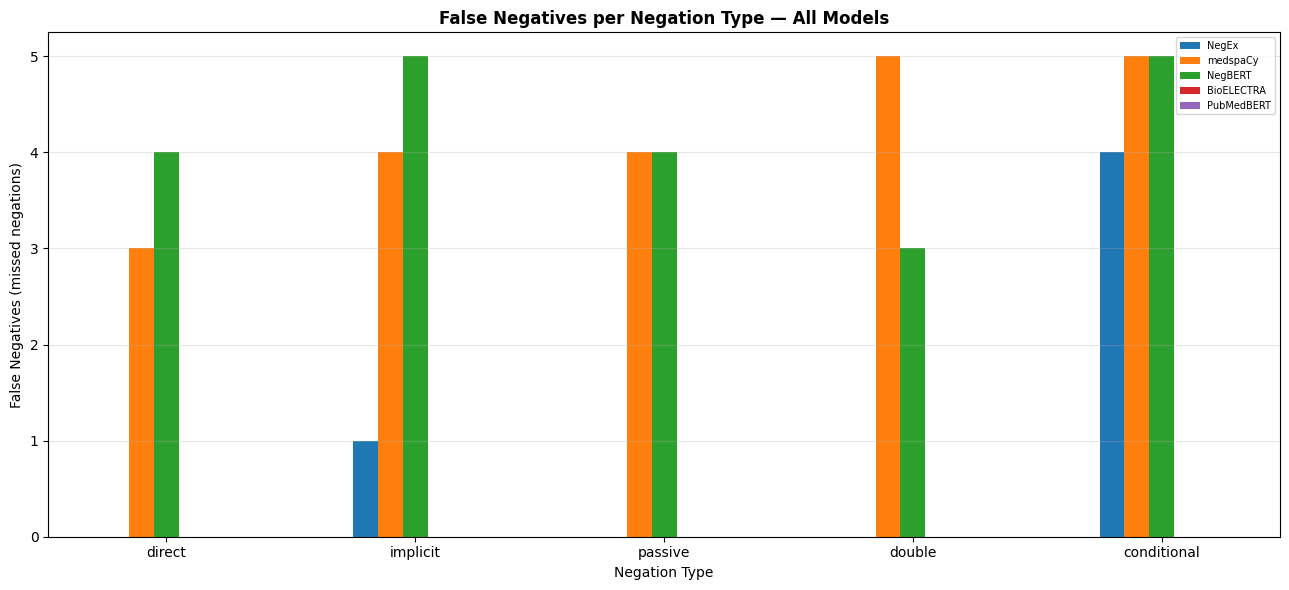

✓ Saved: false_negatives_by_type.png


In [43]:
# False Negative breakdown by type
fn_data = {r["model"]: r["false_negatives"] for r in ALL_RESULTS}
type_order = ["direct", "implicit", "passive", "double", "conditional"]
model_names_short = [r["model"].split("(")[0].strip() for r in ALL_RESULTS]

fn_matrix = []
for r in ALL_RESULTS:
    counts = {t: 0 for t in type_order}
    for fn in r["false_negatives"]:
        if fn["type"] in counts:
            counts[fn["type"]] += 1
    fn_matrix.append([counts[t] for t in type_order])

fn_array = np.array(fn_matrix)
x = np.arange(len(type_order))
width = 0.1
fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, row) in enumerate(zip(model_names_short, fn_matrix)):
    ax.bar(x + i * width, row, width, label=name)

ax.set_xlabel("Negation Type")
ax.set_ylabel("False Negatives (missed negations)")
ax.set_title("False Negatives per Negation Type — All Models", fontweight="bold")
ax.set_xticks(x + width * (len(ALL_RESULTS) - 1) / 2)
ax.set_xticklabels(type_order)
ax.set_yticks(range(6))
ax.legend(fontsize=7, loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("false_negatives_by_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: false_negatives_by_type.png")
